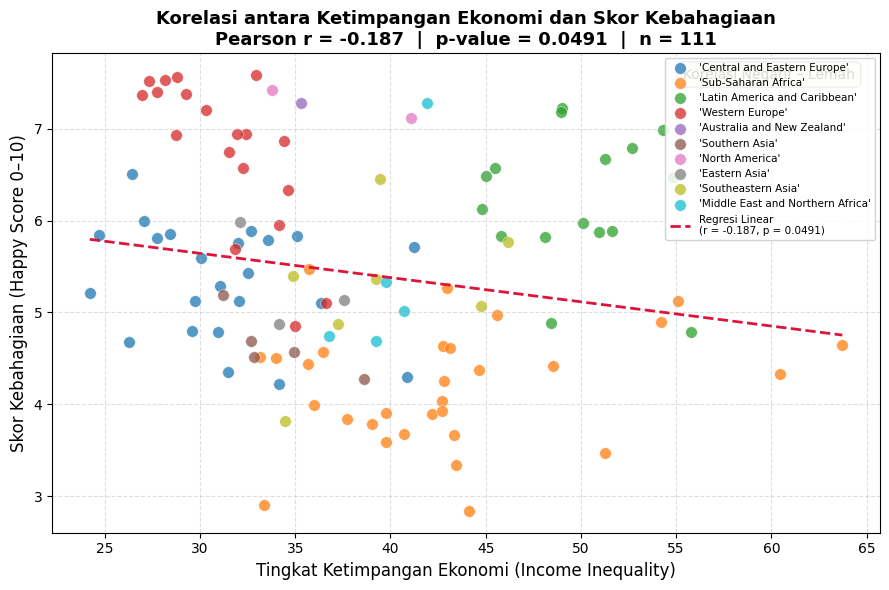


Korelasi Pearson  : -0.1872
P-value           : 0.049112
Kekuatan korelasi : Lemah (Negatif)
Jumlah data       : 111


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import os

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
df = pd.read_csv(
    '/content/Kelas D_Happiness and Satisfaction.csv',
    sep=';',
    decimal=','
)

# Hapus baris dengan nilai NaN pada kolom yang dianalisis
df_clean = df[['Country', 'Region', 'income_inequality', 'Happy Score (0-10)']].dropna()

x = df_clean['income_inequality']
y = df_clean['Happy Score (0-10)']

# ─────────────────────────────────────────────
# 2. HITUNG KORELASI
# ─────────────────────────────────────────────
r, p_value = stats.pearsonr(x, y)

# ─────────────────────────────────────────────
# 3. GRAFIK 3 – KATEGORI C (KORELASI)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

# Scatter plot dengan warna berdasarkan Region
regions = df_clean['Region'].unique()
palette = sns.color_palette('tab10', n_colors=len(regions))
region_color = {region: palette[i] for i, region in enumerate(regions)}

for region in regions:
    subset = df_clean[df_clean['Region'] == region]
    ax.scatter(
        subset['income_inequality'],
        subset['Happy Score (0-10)'],
        label=region,
        color=region_color[region],
        alpha=0.75,
        edgecolors='white',
        linewidths=0.4,
        s=70
    )

# Garis regresi linear
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2,
        linestyle='--', label=f'Regresi Linear\n(r = {r:.3f}, p = {p_value:.4f})')

# Label dan judul
ax.set_xlabel('Tingkat Ketimpangan Ekonomi (Income Inequality)', fontsize=12)
ax.set_ylabel('Skor Kebahagiaan (Happy Score 0–10)', fontsize=12)
ax.set_title(
    'Korelasi antara Ketimpangan Ekonomi dan Skor Kebahagiaan\n'
    f'Pearson r = {r:.3f}  |  p-value = {p_value:.4f}  |  n = {len(df_clean)}',
    fontsize=13, fontweight='bold'
)

# Interpretasi kekuatan korelasi
if abs(r) >= 0.7:
    kekuatan = 'Kuat'
elif abs(r) >= 0.4:
    kekuatan = 'Sedang'
else:
    kekuatan = 'Lemah'

arah = 'Negatif' if r < 0 else 'Positif'
interpretasi = f'Korelasi {arah} – {kekuatan}'

ax.text(
    0.97, 0.97, interpretasi,
    transform=ax.transAxes,
    fontsize=10, verticalalignment='top', horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.9)
)

ax.legend(loc='upper right', fontsize=7.5, framealpha=0.85, ncol=1)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = os.path.dirname('/mnt/user-data/outputs/grafik3_korelasi.png')
os.makedirs(output_dir, exist_ok=True)

plt.savefig('grafik3_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nKorelasi Pearson  : {r:.4f}")
print(f"P-value           : {p_value:.6f}")
print(f"Kekuatan korelasi : {kekuatan} ({arah})")
print(f"Jumlah data       : {len(df_clean)}")